# COMP5329 - Deep Learning 

**Tutorial 7 - CNN Architectures**

**Semester 1, 2025**

**Objectives:**

* To learn about how to build AlexNet and use a pretrained AlexNet to implement classification. 
* To learn about how to finetune AlexNet with your datasets.


## 1. Import Packages

In [ ]:
import io
import os

import torch
from torch import nn

from torchvision import datasets
from torchvision import transforms
from torch.hub import load_state_dict_from_url

from matplotlib import pyplot as plt


from functools import partial
from typing import Any, Callable, List, Optional, Type, Union
from torch import Tensor

## 2. AlexNet

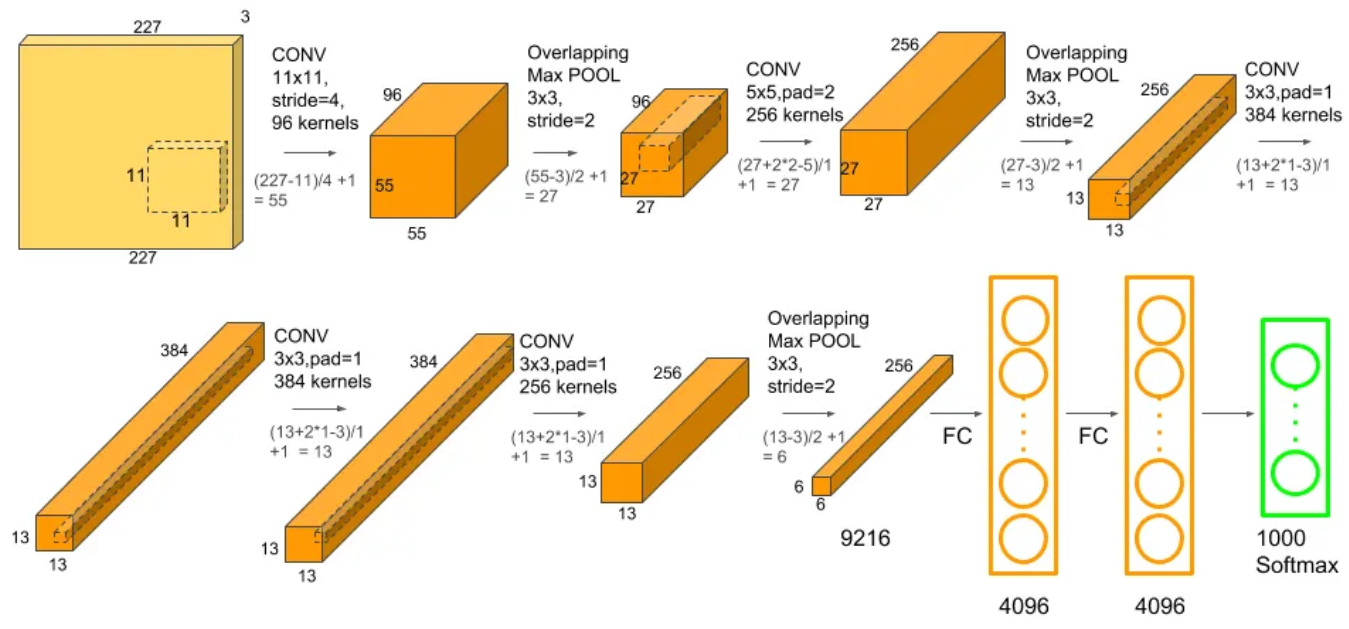

In [ ]:
class AlexNet_Original(nn.Module):

    def __init__(self, num_classes=1000, stem_stride=4):
        # invoke super class initialisation method
        super(AlexNet, self).__init__()
        
        # define the CNN:
        # 1. define feature extraction layers
        self.features = nn.Sequential(
            # conv-relu-pooling (block 1)
            nn.Conv2d(3, 96, kernel_size=11, stride=stem_stride, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # conv-relu-pooling (block 2)
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # conv-relu-conv-relu-conv-relu-pooling (block 3 + 4 + 5)
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        # 2. define average pooling layer
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        # 3. define fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(),                   # use dropout
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),                   # use dropout
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    # define forward-propagation
    def forward(self, x):
        # feature extraction
        x = self.features(x)
        # adaptive pooling
        x = self.avgpool(x)
        # flat the feature map
        x = torch.flatten(x, 1)
        # classification
        x = self.classifier(x)
        return x

    # back-propagation is handled by PyTorch

### 2.1 Pytorch Implementation

In [ ]:
class AlexNet(nn.Module):

    def __init__(self, num_classes=1000, stem_stride=4):
        # invoke super class initialisation method
        super(AlexNet, self).__init__()
        
        # define the CNN:
        # 1. define feature extraction layers
        self.features = nn.Sequential(
            # conv-relu-pooling
            nn.Conv2d(3, 64, kernel_size=11, stride=stem_stride, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # conv-relu-pooling
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # conv-relu-conv-relu-conv-relu-pooling
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        # 2. define average pooling layer
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        # 3. define fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(),                   # use dropout
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),                   # use dropout
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    # define forward-propagation
    def forward(self, x):
        # feature extraction
        x = self.features(x)
        # adaptive pooling
        x = self.avgpool(x)
        # flat the feature map
        x = torch.flatten(x, 1)
        # classification
        x = self.classifier(x)
        return x

    # back-propagation is handled by PyTorch

## 3. Classification with Pretrained Model
### 3.1 Pretrained AlexNet from TorchVision

In [ ]:
# pretrained model url
alexnet_url = "https://download.pytorch.org/models/alexnet-owt-4df8aa71.pth"

# create a network
model = AlexNet()
# load pretrained network from url
state_dict = load_state_dict_from_url(alexnet_url)
model.load_state_dict(state_dict)

# utilise GPU
if torch.cuda.is_available():
    print('using GPU')
    model = model.to('cuda')
else:
    print('using CPU')

NameError: ignored

###  3.2 Download test images

In [ ]:
%%bash

if [ -d img ]; then rm -rf img; fi

mkdir -p img/llama
wget "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b9/Llama_lying_down.jpg/1200px-Llama_lying_down.jpg" -P img/llama

mkdir -p img/sealion
wget "https://upload.wikimedia.org/wikipedia/commons/thumb/7/74/California_sea_lion_in_La_Jolla_%2870568%29.jpg/1920px-California_sea_lion_in_La_Jolla_%2870568%29.jpg" -P img/sealion

mkdir -p img/zebra
wget "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9c/Zebra_in_Mikumi.JPG/1920px-Zebra_in_Mikumi.JPG" -P img/zebra

### 3.3 Import class names from uploaded file

In [ ]:
# you need upload `class_names.py` manually
# or you can find the code in the end of this notebook (the final block)
# from class_names import class_names

ModuleNotFoundError: ignored

### 3.4 Make Prediction

In [ ]:
data = datasets.ImageFolder(
    'img',
    transforms.Compose([
        transforms.ToTensor(),
        # use ImageNet statistics to normalize
        # (the pretrained model is trained on ImageNet)
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]))
data_queue = torch.utils.data.DataLoader(data)

NameError: name 'datasets' is not defined

torch.Size([1, 3, 800, 1200])
torch.Size([1, 3, 1487, 1920])
torch.Size([1, 3, 1465, 1920])


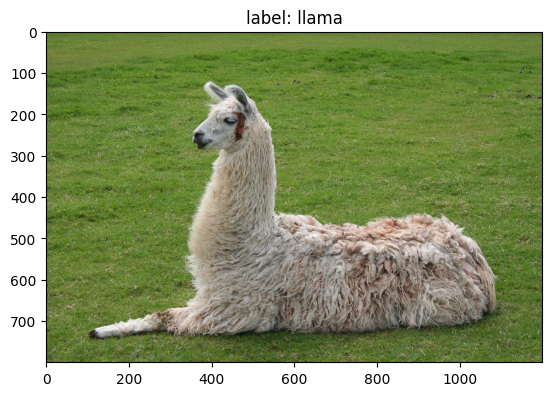

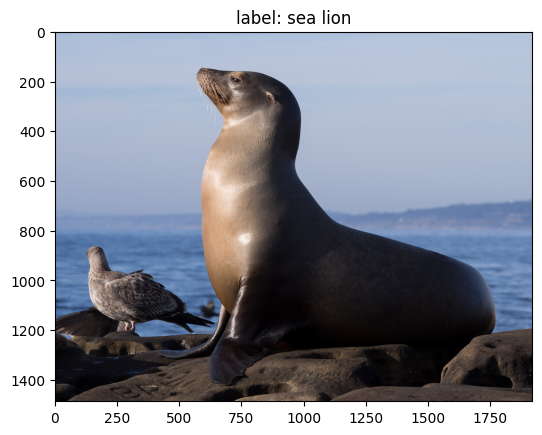

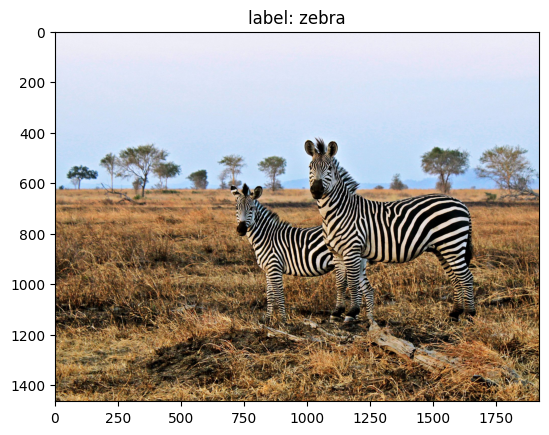

<Figure size 640x480 with 0 Axes>

In [ ]:
# set model to evaluation mode
model.eval()
# make prediction
for x, y in data_queue:

    plt.imshow(x[0].transpose(0, 1).transpose(1, 2)
               * torch.tensor([0.229, 0.224, 0.225])
               + torch.tensor([0.485, 0.456, 0.406]))

    if torch.cuda.is_available():
        x = x.to('cuda')

    p = model(x)
    print(x.shape)
    
    plt.title('label: %s' % (class_names[p.argmax()]))
    
    plt.figure()

## 4. Train AlexNet with New Data (CIFAR-10)

In [ ]:
# calculate top-k accuracy
def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].view(-1).float().sum(0)
        res.append(correct_k.mul_(100.0/batch_size))
    return res

In [ ]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.49139968, 0.48215827, 0.44653124],
                         std=[0.24703233, 0.24348505, 0.26158768])
])

train_set = datasets.CIFAR10(root='./data', train=True,
                             download=True, transform=transform)
train_queue = torch.utils.data.DataLoader(train_set, batch_size=32,
                                          shuffle=True, num_workers=2)

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.49139968, 0.48215827, 0.44653124],
                         std=[0.24703233, 0.24348505, 0.26158768])
])

test_set = datasets.CIFAR10(root='./data', train=False,
                            download=True, transform=test_transforms)
test_queue = torch.utils.data.DataLoader(test_set, batch_size=32,
                                         shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


You can use GPU. This might take a while.

In [ ]:
learning_rate = 0.1
epochs = 10

# create a network
model = AlexNet(num_classes=10, stem_stride=1)

# utilise GPU
if torch.cuda.is_available():
    print('using GPU')
    model = model.to('cuda')
else:
    print('using CPU')

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), learning_rate)

# define loss function
criterion = nn.CrossEntropyLoss()

# training
## set model to training mode
model.train()
## start training
for ep in range(epochs):
    ep_loss = 0.0
    ep_acc = 0.0
    for step, (x, y) in enumerate(train_queue):
        if torch.cuda.is_available():
            x = x.to('cuda')
            y = y.to('cuda')
        # set gradient to zero        
        optimizer.zero_grad()
        # calculate output
        p = model(x)
        # calculate metrics
        loss = criterion(p, y)
        acc = accuracy(p, y)
        ep_loss += loss
        ep_acc += acc[0]
        # back-prop
        loss.backward()
        # update parameters
        optimizer.step()
        if step % 100 == 0:
            print('\repoch: %d step: %d loss: %.2f acc: %.4f'
                  % (ep, step, ep_loss/(step+1), ep_acc/(step+1)), end='')
    print('\nepoch: %d loss: %.2f acc: %.4f'
          % (ep, ep_loss/(step+1), ep_acc/(step+1)))

using GPU
epoch: 0 step: 1500 loss: 2.06 acc: 19.8430
epoch: 0 loss: 2.05 acc: 20.2715
epoch: 1 step: 1500 loss: 1.67 acc: 38.1163
epoch: 1 loss: 1.67 acc: 38.3357
epoch: 2 step: 1500 loss: 1.44 acc: 47.9826
epoch: 2 loss: 1.44 acc: 48.1666
epoch: 3 step: 1500 loss: 1.26 acc: 55.3194
epoch: 3 loss: 1.26 acc: 55.4023
epoch: 4 step: 1500 loss: 1.14 acc: 60.5825
epoch: 4 loss: 1.14 acc: 60.6806
epoch: 5 step: 1500 loss: 1.06 acc: 63.5889
epoch: 5 loss: 1.06 acc: 63.6856
epoch: 6 step: 1500 loss: 0.99 acc: 66.0914
epoch: 6 loss: 0.99 acc: 66.1308
epoch: 7 step: 1500 loss: 0.95 acc: 68.1754
epoch: 7 loss: 0.94 acc: 68.2562
epoch: 8 step: 1500 loss: 0.90 acc: 69.8347
epoch: 8 loss: 0.90 acc: 69.7957
epoch: 9 step: 1500 loss: 0.87 acc: 70.6404
epoch: 9 loss: 0.87 acc: 70.6674


In [ ]:
# evaluation
## set model to evaluation mode
model.eval()
## evaluation
ep_loss = 0.0
ep_acc = 0.0
for step, (x, y) in enumerate(test_queue):
    if torch.cuda.is_available():
        x = x.to('cuda')
        y = y.to('cuda')
    # calculate output
    p = model(x)
    # calculate metrics
    loss = criterion(p, y)
    acc = accuracy(p, y)
    ep_loss += loss
    ep_acc += acc[0]
    if step % 100 == 0:
        print('\rtest step: %d loss: %.2f acc: %.4f'
                % (step, ep_loss/(step+1), ep_acc/(step+1)), end='')
print('\ntest loss: %.2f acc: %.4f'
        % (ep_loss/(step+1), ep_acc/(step+1)))

test step: 300 loss: 1.06 acc: 63.6109
test loss: 1.06 acc: 63.4884


In [ ]:
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

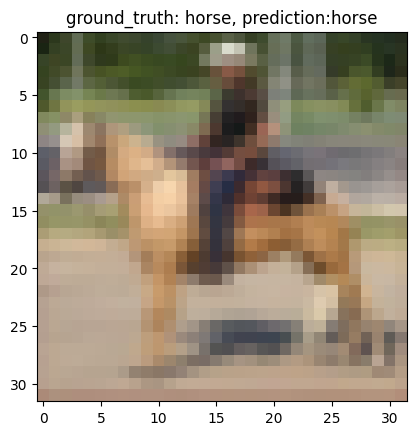

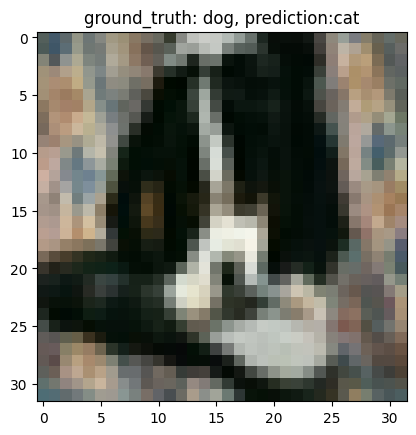

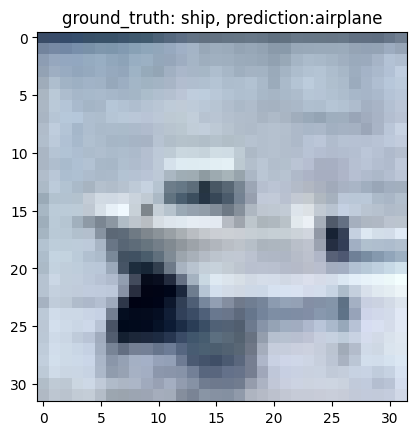

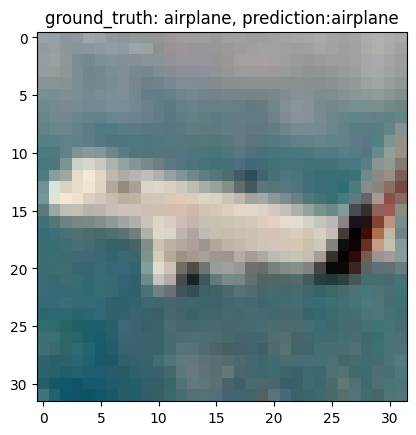

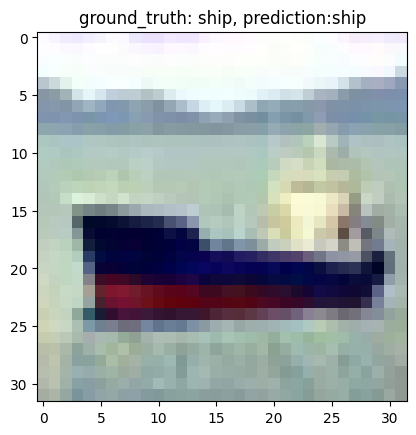

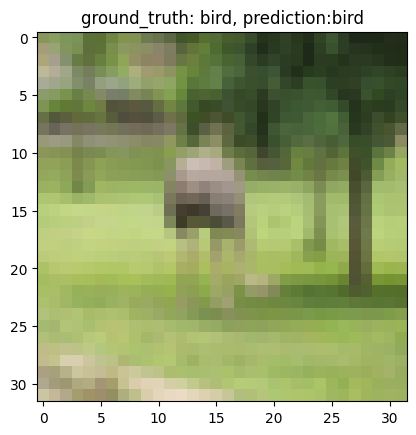

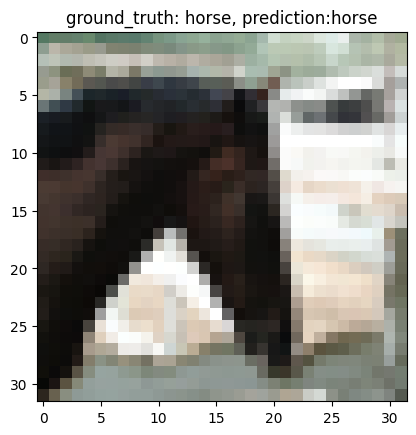

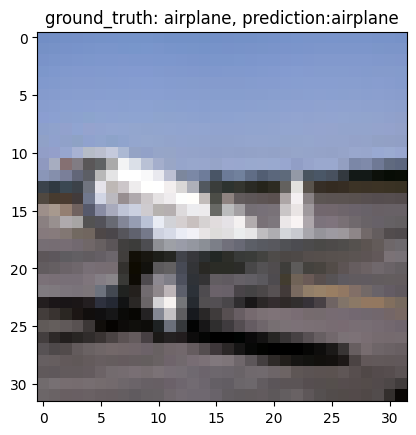

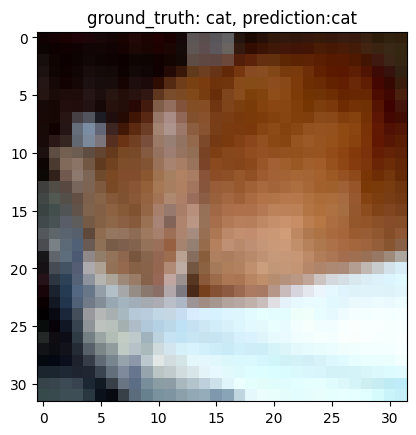

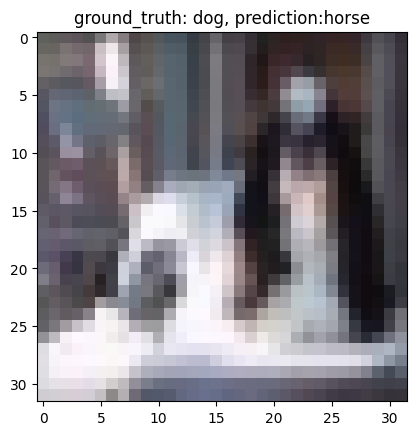

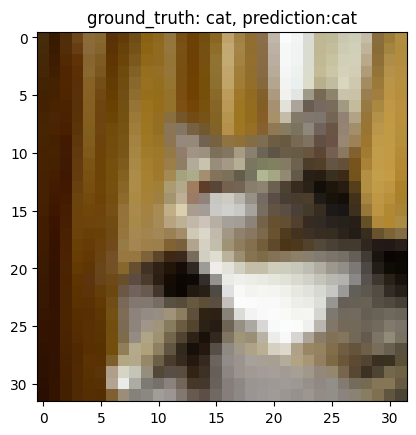

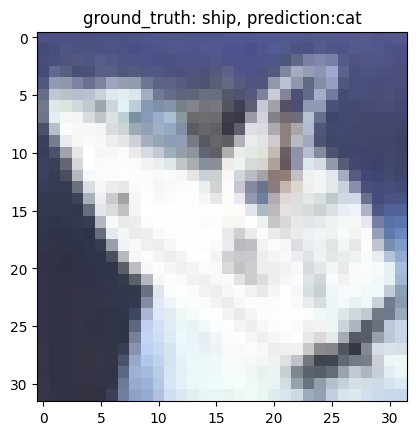

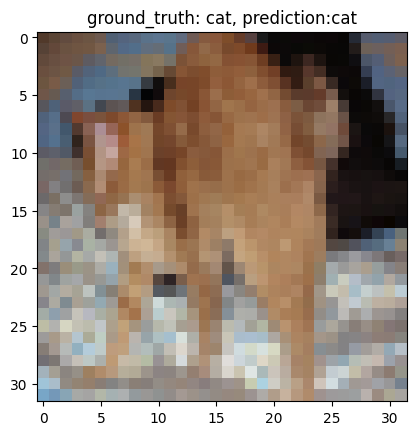

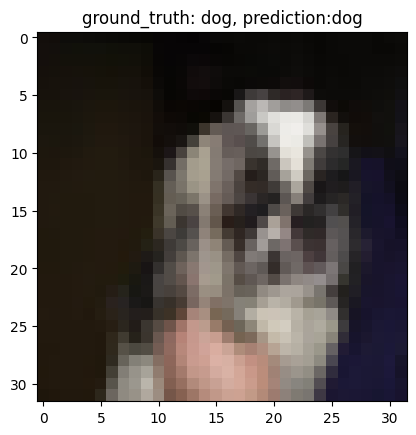

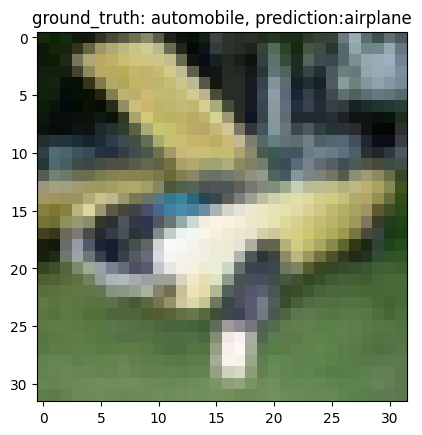

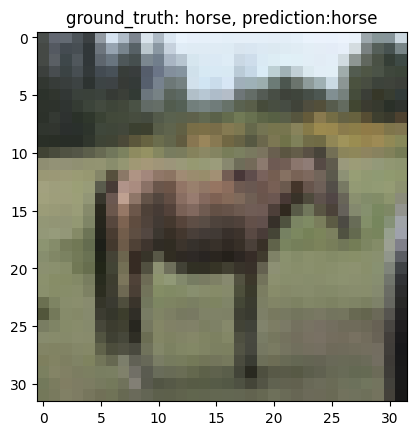

In [ ]:
for img, ground_truth, prediction in zip(x.to('cpu'), y.to('cpu'), p.to('cpu')):
    plt.imshow(img.transpose(0, 1).transpose(1, 2)
               * torch.tensor([0.24703233, 0.24348505, 0.26158768])
               + torch.tensor([0.49139968, 0.48215827, 0.44653124],))
    plt.title('ground_truth: %s, prediction:%s'
              % (cifar10_class_names[ground_truth],
                 cifar10_class_names[prediction.argmax()]))
    plt.show()

## 5. VGG-11

In [ ]:
class VGG11_IMN(nn.Module):

    def __init__(self, num_classes=1000, stem_stride=1):
        # invoke super class initialisation method
        super(VGG11_IMN, self).__init__()
        
        # define the CNN:
        # 1. define feature extraction layers
        self.features = nn.Sequential(
            # conv-relu-pooling
            nn.Conv2d(3, 64, kernel_size=3, stride=stem_stride, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # conv-relu-pooling
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
  
        # 2. define fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(),                   # use dropout
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),                   # use dropout
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    # define forward-propagation
    def forward(self, x):
        # feature extraction
        x = self.features(x)

        # flat the feature map
        x = torch.flatten(x, 1)
        # classification
        x = self.classifier(x)
        return x

    # back-propagation is handled by PyTorch

In [ ]:
class VGG11_CIFAR10(nn.Module):

    def __init__(self, num_classes=1000, stem_stride=1):
        # invoke super class initialisation method
        super(VGG11_CIFAR10, self).__init__()
        
        # define the CNN:
        # 1. define feature extraction layers
        self.features = nn.Sequential(
            # conv-relu-pooling
            nn.Conv2d(3, 64, kernel_size=3, stride=stem_stride, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # conv-relu-pooling
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv-relu-pooling
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
  
        # 2. define fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(),                   # use dropout
            nn.Linear(512 * 1 * 1, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(),                   # use dropout
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, num_classes),
        )

    # define forward-propagation
    def forward(self, x):
        # feature extraction
        x = self.features(x)
        # flat the feature map
        x = torch.flatten(x, 1)
        # classification
        x = self.classifier(x)
        return x

    # back-propagation is handled by PyTorch

In [ ]:
transform = transforms.Compose([
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.49139968, 0.48215827, 0.44653124],
                         std=[0.24703233, 0.24348505, 0.26158768])
])

train_set = datasets.CIFAR10(root='./data', train=True,
                             download=True, transform=transform)
train_queue = torch.utils.data.DataLoader(train_set, batch_size=32,
                                          shuffle=True, num_workers=2)

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.49139968, 0.48215827, 0.44653124],
                         std=[0.24703233, 0.24348505, 0.26158768])
])

test_set = datasets.CIFAR10(root='./data', train=False,
                            download=True, transform=test_transforms)
test_queue = torch.utils.data.DataLoader(test_set, batch_size=32,
                                         shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
learning_rate = 0.1
epochs = 10

# create a network
model = VGG11_CIFAR10(num_classes=10, stem_stride=1)

# utilise GPU
if torch.cuda.is_available():
    print('using GPU')
    model = model.to('cuda')
else:
    print('using CPU')

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), learning_rate)

# define loss function
criterion = nn.CrossEntropyLoss()

# training
## set model to training mode
model.train()
## start training
for ep in range(epochs):
    ep_loss = 0.0
    ep_acc = 0.0
    for step, (x, y) in enumerate(train_queue):
        if torch.cuda.is_available():
            x = x.to('cuda')
            y = y.to('cuda')
        # set gradient to zero        
        optimizer.zero_grad()
        # calculate output
        p = model(x)
        # calculate metrics
        loss = criterion(p, y)
        acc = accuracy(p, y)
        ep_loss += loss
        ep_acc += acc[0]
        # back-prop
        loss.backward()
        # update parameters
        optimizer.step()
        if step % 100 == 0:
            print('\repoch: %d step: %d loss: %.2f acc: %.4f'
                  % (ep, step, ep_loss/(step+1), ep_acc/(step+1)), end='')
    print('\nepoch: %d loss: %.2f acc: %.4f'
          % (ep, ep_loss/(step+1), ep_acc/(step+1)))

using GPU
epoch: 0 step: 1500 loss: 2.30 acc: 10.0516
epoch: 0 loss: 2.30 acc: 10.0848
epoch: 1 step: 1500 loss: 2.14 acc: 15.9519
epoch: 1 loss: 2.13 acc: 16.2688
epoch: 2 step: 1500 loss: 1.76 acc: 30.6795
epoch: 2 loss: 1.75 acc: 30.9701
epoch: 3 step: 1500 loss: 1.47 acc: 45.2573
epoch: 3 loss: 1.46 acc: 45.5174
epoch: 4 step: 1500 loss: 1.15 acc: 59.1314
epoch: 4 loss: 1.15 acc: 59.2370
epoch: 5 step: 1500 loss: 0.92 acc: 68.4669
epoch: 5 loss: 0.92 acc: 68.5181
epoch: 6 step: 1500 loss: 0.77 acc: 73.8799
epoch: 6 loss: 0.77 acc: 73.9483
epoch: 7 step: 1500 loss: 0.66 acc: 78.0917
epoch: 7 loss: 0.66 acc: 78.1750
epoch: 8 step: 1500 loss: 0.58 acc: 80.6775
epoch: 8 loss: 0.58 acc: 80.7342
epoch: 9 step: 1500 loss: 0.52 acc: 83.0446
epoch: 9 loss: 0.52 acc: 83.0454


In [ ]:
# evaluation
## set model to evaluation mode
model.eval()
## evaluation
ep_loss = 0.0
ep_acc = 0.0
for step, (x, y) in enumerate(test_queue):
    if torch.cuda.is_available():
        x = x.to('cuda')
        y = y.to('cuda')
    # calculate output
    p = model(x)
    # calculate metrics
    loss = criterion(p, y)
    acc = accuracy(p, y)
    ep_loss += loss
    ep_acc += acc[0]
    if step % 100 == 0:
        print('\rtest step: %d loss: %.2f acc: %.4f'
                % (step, ep_loss/(step+1), ep_acc/(step+1)), end='')
print('\ntest loss: %.2f acc: %.4f'
        % (ep_loss/(step+1), ep_acc/(step+1)))

test step: 300 loss: 0.66 acc: 78.8310
test loss: 0.66 acc: 78.6741


In [ ]:
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
for img, ground_truth, prediction in zip(x.to('cpu'), y.to('cpu'), p.to('cpu')):
    plt.imshow(img.transpose(0, 1).transpose(1, 2)
               * torch.tensor([0.24703233, 0.24348505, 0.26158768])
               + torch.tensor([0.49139968, 0.48215827, 0.44653124],))
    plt.title('ground_truth: %s, prediction:%s'
              % (cifar10_class_names[ground_truth],
                 cifar10_class_names[prediction.argmax()]))
    plt.show()

## 6. Resnet

### Skip connection implementation

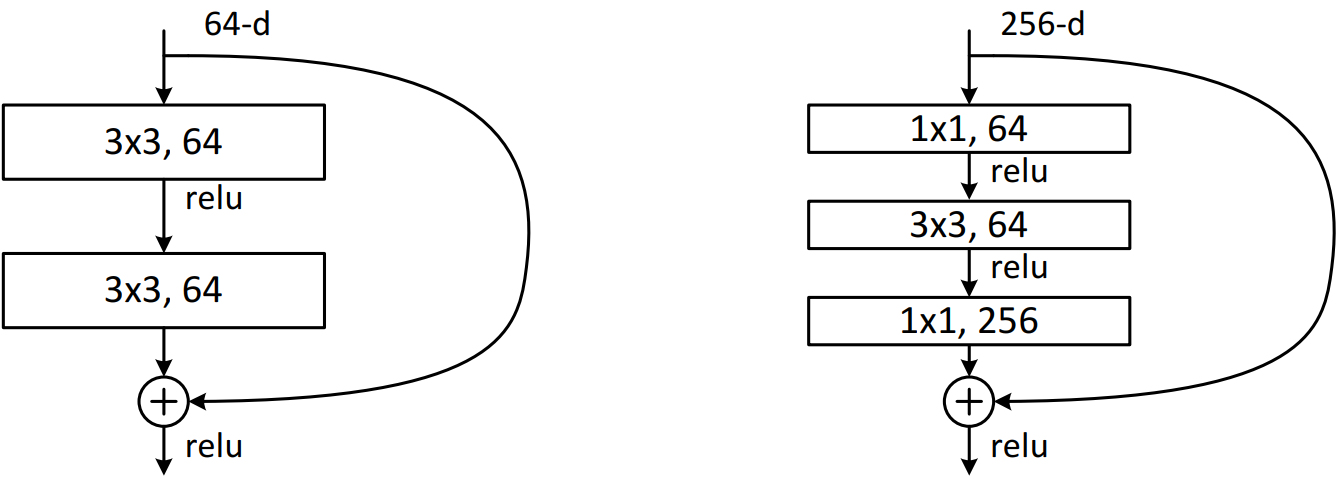

In [ ]:
def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

In [ ]:
class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
# TODO bottleneck 

class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition" https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


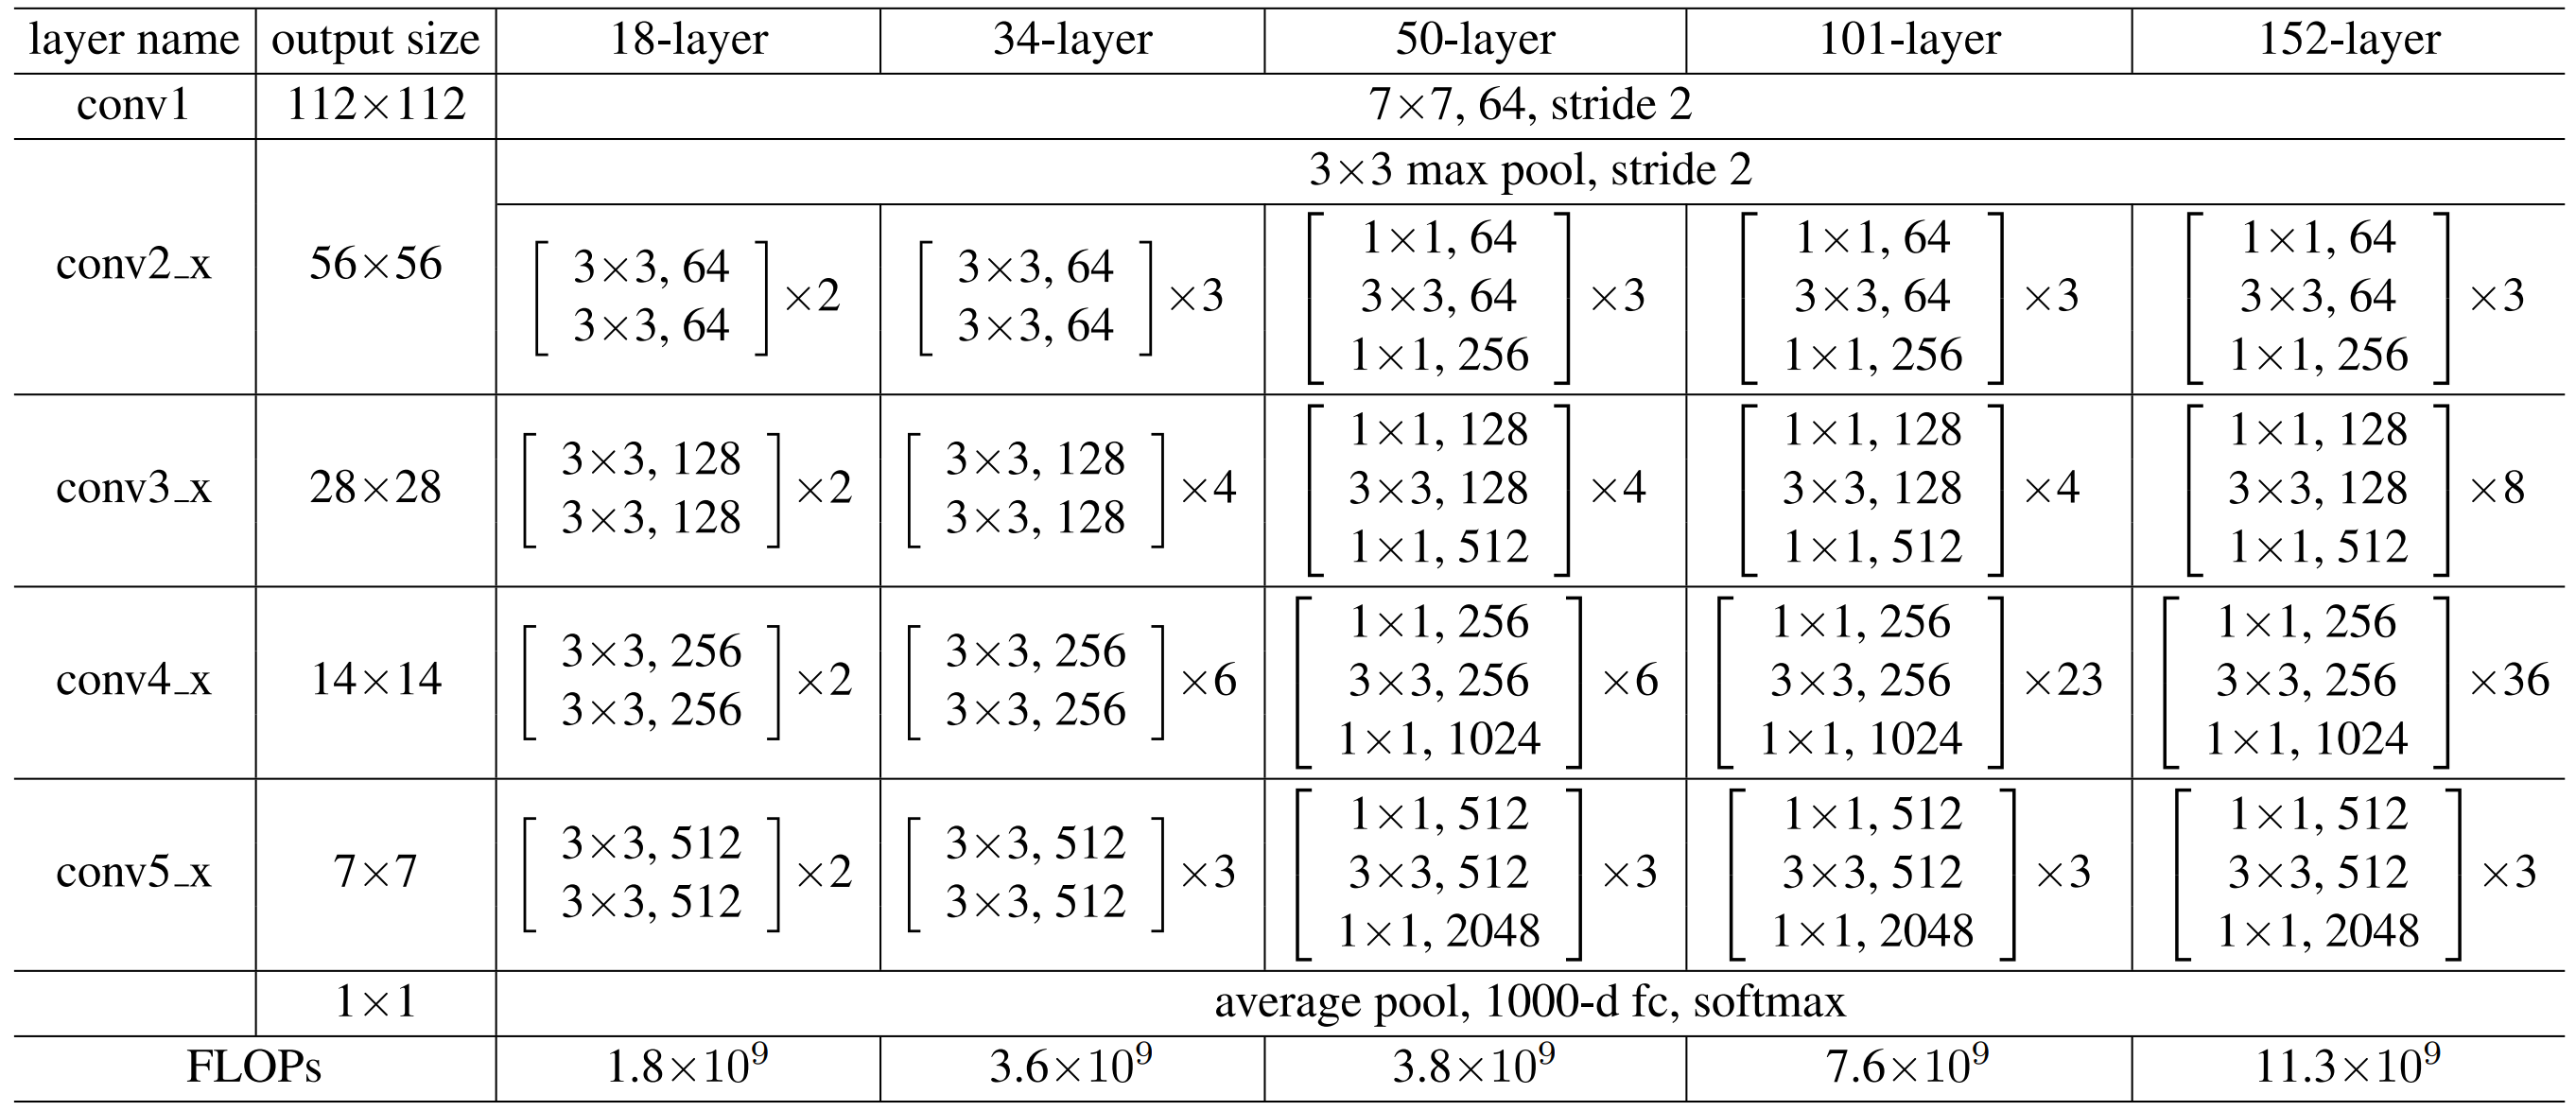